# 1 Install Libraries

In [1]:
!pip install gym stable-baselines3 ta

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 6.3 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=235998bc9e15b9051f272b29f0d4a90db410498e8b1bede60ee584fb1ec536f1
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


# 2 Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

import gym
from gym import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

import ta

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
2026-03-01 06:42:03.962040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772347324.175935      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772347324.237666      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register 

# 3 Download European Market Data

In [3]:
tickers = ["SAP.DE","SIE.DE","ADS.DE"]

data = yf.download(tickers,start="2015-01-01")["Close"]

data = data.dropna()

data.head()

/tmp/ipykernel_17/1586166787.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers,start="2015-01-01")["Close"]
[*********************100%***********************]  3 of 3 completed


Ticker,ADS.DE,SAP.DE,SIE.DE
Date,,,
2015-01-02,50.100456,49.115639,57.480675
2015-01-05,48.617512,47.497005,55.745708
2015-01-06,48.493195,46.426342,55.696663
2015-01-07,48.981590,46.257732,56.052238
2015-01-08,50.597736,47.269371,57.885307


# 4 Feature Engineering

In [4]:
df = pd.DataFrame()

df["price"] = data["SAP.DE"]

df["returns"] = df["price"].pct_change()

df["rsi"] = ta.momentum.RSIIndicator(df["price"]).rsi()

df["volatility"] = df["returns"].rolling(20).std()

df["sma"] = df["price"].rolling(20).mean()

df = df.dropna()

# 5 Create Trading Environment

In [5]:
class TradingEnv(gym.Env):

    def __init__(self, df):

        super(TradingEnv, self).__init__()

        self.df = df.reset_index(drop=True)

        self.current_step = 0

        # actions: hold, buy, sell
        self.action_space = spaces.Discrete(3)

        # observations
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(4,),
            dtype=np.float32
        )

        self.initial_cash = 10000

        self.reset()

## Step Function

In [6]:
    def step(self, action):

        price = self.df["price"].iloc[self.current_step]

        if action == 1:  # buy
            if self.cash > 0:
                self.shares = self.cash / price
                self.cash = 0
                self.position = 1

        elif action == 2:  # sell
            if self.shares > 0:
                self.cash = self.shares * price
                self.shares = 0
                self.position = 0

        self.current_step += 1

        portfolio_value = self.cash + self.shares * price

        reward = portfolio_value

        terminated = self.current_step >= len(self.df) - 1
        truncated = False

        obs = self._next_observation()

        info = {}

        return obs, reward, terminated, truncated, info

## Observation Function

In [7]:
    def _next_observation(self):

        obs = np.array([
            self.df["returns"].iloc[self.current_step],
            self.df["rsi"].iloc[self.current_step],
            self.df["volatility"].iloc[self.current_step],
            self.position
        ], dtype=np.float32)

        return obs

## Reset

In [8]:
    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.current_step = 0
        self.cash = self.initial_cash
        self.shares = 0
        self.position = 0

        obs = self._next_observation()

        info = {}

        return obs, info

In [9]:
class TradingEnv(gym.Env):

    def __init__(self, df):

        super().__init__()

        self.df = df.reset_index(drop=True)
        self.current_step = 0

        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(4,),
            dtype=np.float32
        )

        self.cash = 10000
        self.shares = 0
        self.position = 0

    def _get_obs(self):

        obs = np.array([
            self.df["returns"].iloc[self.current_step],
            self.df["rsi"].iloc[self.current_step],
            self.df["volatility"].iloc[self.current_step],
            self.position
        ], dtype=np.float32)

        return obs

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.current_step = 0
        self.cash = 10000
        self.shares = 0
        self.position = 0

        obs = self._get_obs()

        return obs, {}

    def step(self, action):

        price = self.df["price"].iloc[self.current_step]

        if action == 1:  # buy
            if self.cash > 0:
                self.shares = self.cash / price
                self.cash = 0
                self.position = 1

        elif action == 2:  # sell
            if self.shares > 0:
                self.cash = self.shares * price
                self.shares = 0
                self.position = 0

        self.current_step += 1

        portfolio_value = self.cash + self.shares * price

        reward = portfolio_value

        terminated = self.current_step >= len(self.df) - 1
        truncated = False

        obs = self._get_obs()

        return obs, reward, terminated, truncated, {}

# 6 Create Environment

In [10]:
from stable_baselines3.common.vec_env import DummyVecEnv

env = DummyVecEnv([lambda: TradingEnv(df)])

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


# 7 Train RL Agent

* used PPO (Proximal Policy Optimization).

In [11]:
model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=0.0003,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    verbose=1)

model.learn(total_timesteps=20000)

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1231 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 948           |
|    iterations           | 2             |
|    time_elapsed         | 4             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 1.9615982e-08 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.1          |
|    explained_variance   | 0             |
|    learning_rate        | 0.0003        |
|    loss                 | 2.73e+10      |
|    n_updates            | 10            |
|    policy_gradient_loss | -4.46e-07     |
|    value_loss           | 5.79e+10      |
-------------------------

# 8 Test Agent

In [12]:
env_test = TradingEnv(df)

obs, _ = env_test.reset()

portfolio_values = []

for i in range(len(df)-1):

    action, _ = model.predict(obs)

    obs, reward, done, truncated, info = env_test.step(action)

    portfolio_values.append(reward)

    if done:
        break

# 9 Plot Portfolio

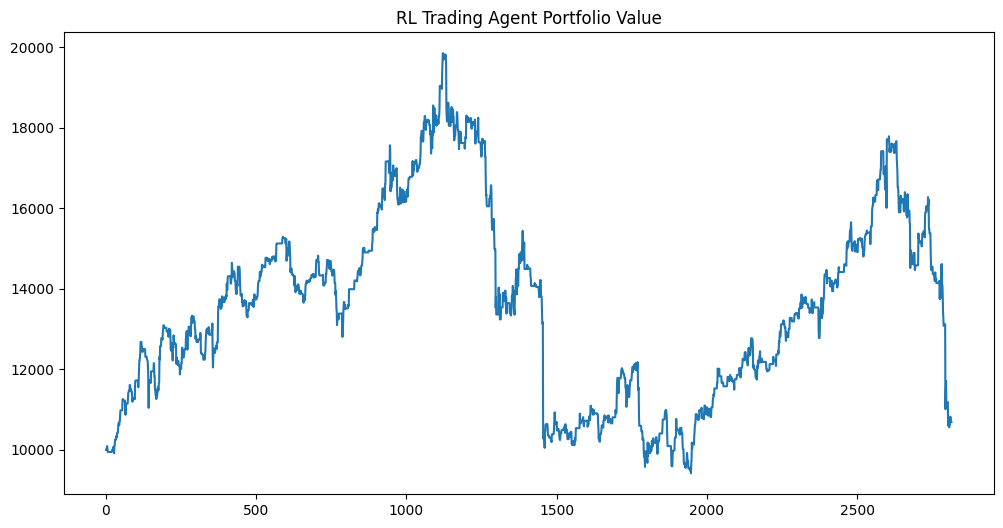

In [13]:
plt.figure(figsize=(12,6))

plt.plot(portfolio_values)

plt.title("RL Trading Agent Portfolio Value")

plt.show()

# 10 Performance Metrics

In [14]:
returns = pd.Series(portfolio_values).pct_change().dropna()

sharpe = np.sqrt(252)*returns.mean()/returns.std()

print("Sharpe Ratio:",sharpe)

print("Total Return:",portfolio_values[-1]/portfolio_values[0]-1)

Sharpe Ratio: 0.12750614277522457
Total Return: 0.06905499398768278
